In [12]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="absenteeism-risk-platform")

query = """
    SELECT *
    FROM `absenteeism-risk-platform.absenteeism_analytics.absenteeism_cleaned`
"""

df = client.query(query).to_dataframe()

print(df.shape)
df.head()

c:\Users\shrey\OneDrive\Desktop\Projects\Data-ScientistPRoject\absenteeism-risk-platform\venv\Lib\site-packages\google\cloud\bigquery\table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(662, 17)


,ID,reason_1,reason_2,reason_3,reason_4,month_value,day_of_week,transportation_expense,distance_to_work,age,daily_work_load_average,body_mass_index,education_binary,children,pets,absenteeism_hours,excessive_absenteeism
0,3,0,0,0,1,7,4,179,51,38,239.554,31,0,0,0,2,0
1,3,0,0,0,1,7,6,179,51,38,239.554,31,0,0,0,2,0
2,3,1,0,0,0,7,4,179,51,38,239.554,31,0,0,0,1,0
3,3,0,0,0,1,7,4,179,51,38,239.554,31,0,0,0,4,1
4,3,0,0,0,1,7,6,179,51,38,239.554,31,0,0,0,2,0


In [13]:
df.info()
print("\nTarget balance:")
print(df['excessive_absenteeism'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       662 non-null    Int64  
 1   reason_1                 662 non-null    Int64  
 2   reason_2                 662 non-null    Int64  
 3   reason_3                 662 non-null    Int64  
 4   reason_4                 662 non-null    Int64  
 5   month_value              662 non-null    Int64  
 6   day_of_week              662 non-null    Int64  
 7   transportation_expense   662 non-null    Int64  
 8   distance_to_work         662 non-null    Int64  
 9   age                      662 non-null    Int64  
 10  daily_work_load_average  662 non-null    float64
 11  body_mass_index          662 non-null    Int64  
 12  education_binary         662 non-null    Int64  
 13  children                 662 non-null    Int64  
 14  pets                     6

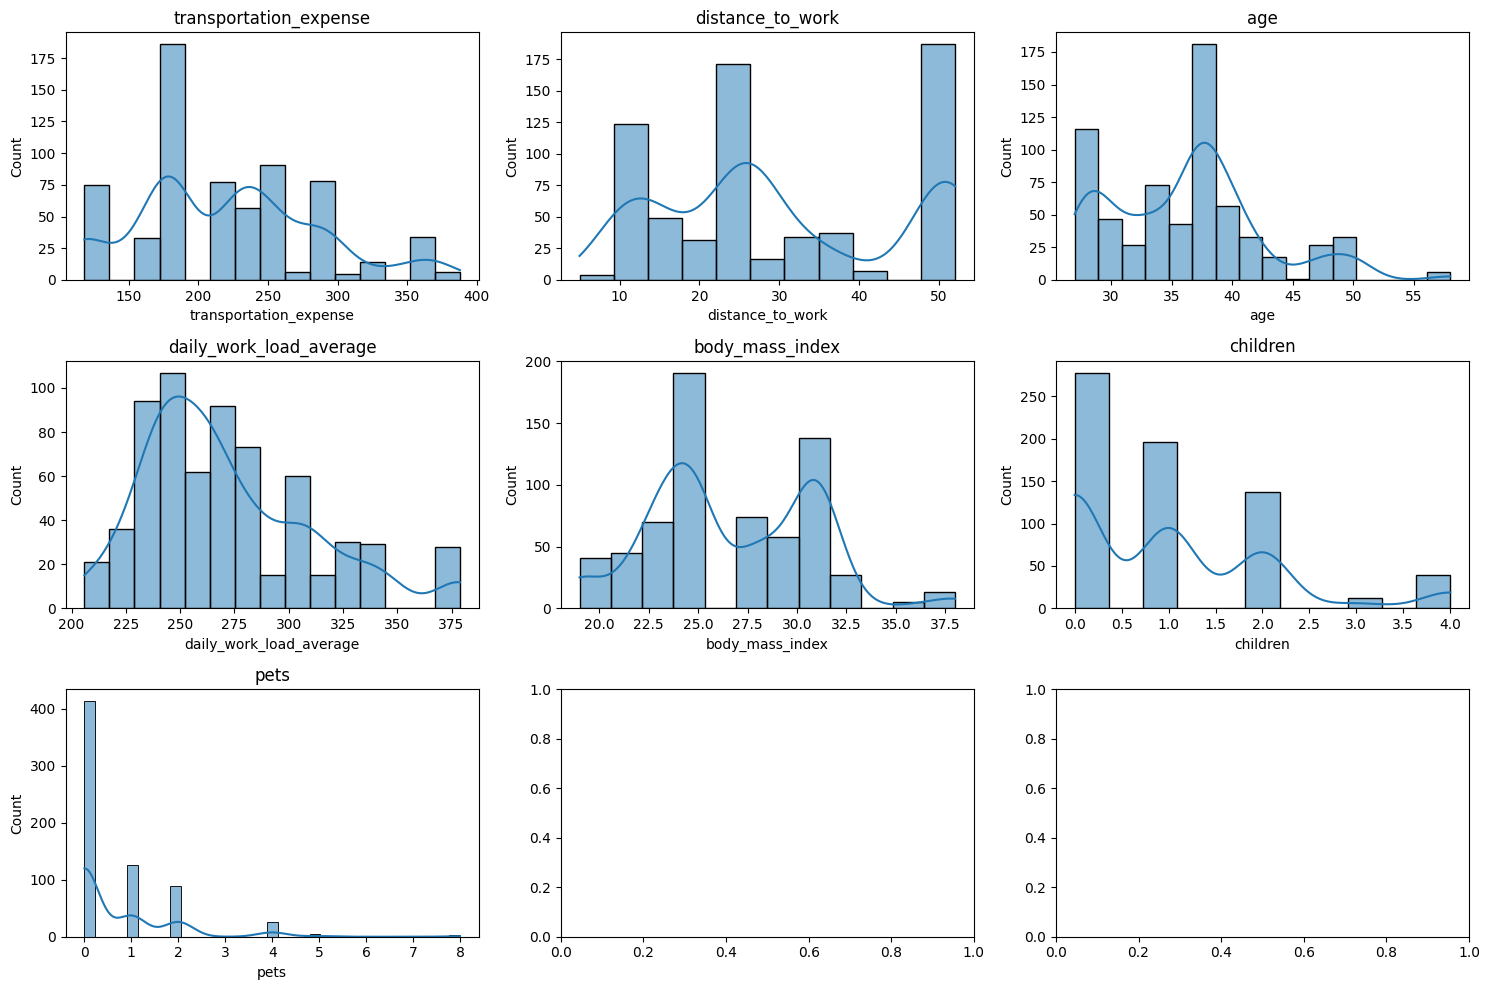

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['transportation_expense', 'distance_to_work', 'age',
                 'daily_work_load_average', 'body_mass_index', 'children', 'pets']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions.png', dpi=150)
plt.show()

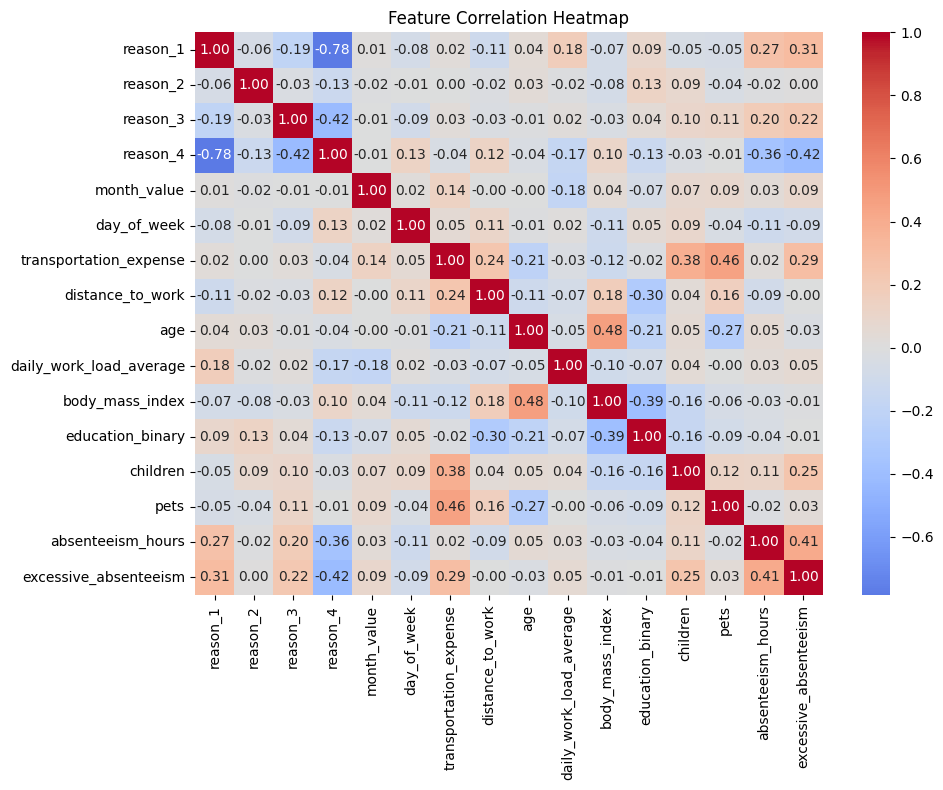

In [15]:
plt.figure(figsize=(10, 8))
corr = df.drop(columns=['ID']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

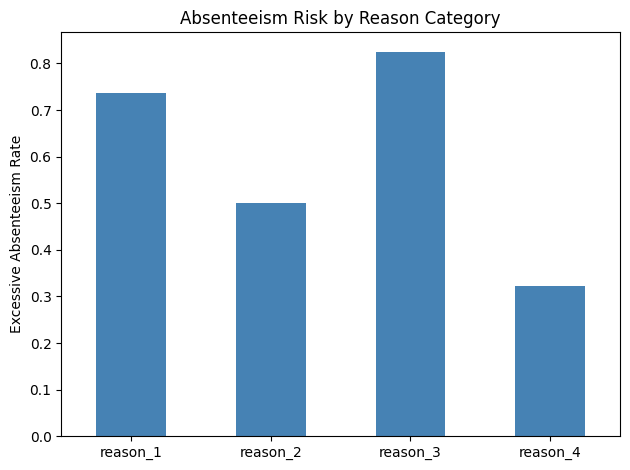

In [16]:
reason_cols = ['reason_1', 'reason_2', 'reason_3', 'reason_4']
rates = {}
for col in reason_cols:
    rates[col] = df[df[col] == 1]['excessive_absenteeism'].mean()

pd.Series(rates).plot(kind='bar', color='steelblue')
plt.ylabel("Excessive Absenteeism Rate")
plt.title("Absenteeism Risk by Reason Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/risk_by_reason.png', dpi=150)
plt.show()

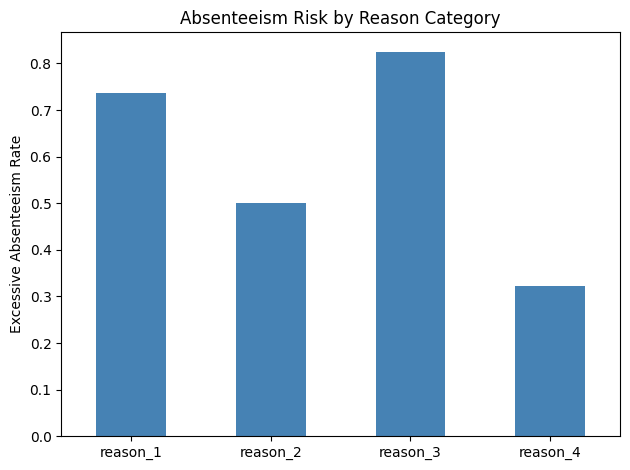

In [17]:
reason_cols = ['reason_1', 'reason_2', 'reason_3', 'reason_4']
rates = {}
for col in reason_cols:
    rates[col] = df[df[col] == 1]['excessive_absenteeism'].mean()

pd.Series(rates).plot(kind='bar', color='steelblue')
plt.ylabel("Excessive Absenteeism Rate")
plt.title("Absenteeism Risk by Reason Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/risk_by_reason.png', dpi=150)
plt.show()

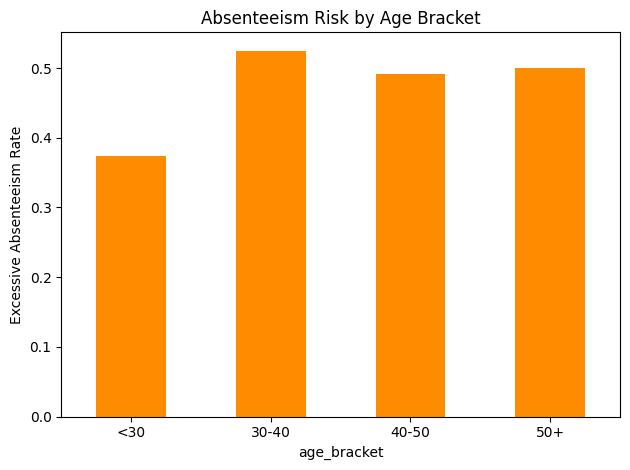

In [18]:
df['age_bracket'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 100],
                            labels=['<30', '30-40', '40-50', '50+'])

age_risk = df.groupby('age_bracket', observed=True)['excessive_absenteeism'].mean()

age_risk.plot(kind='bar', color='darkorange')
plt.ylabel("Excessive Absenteeism Rate")
plt.title("Absenteeism Risk by Age Bracket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/risk_by_age.png', dpi=150)
plt.show()

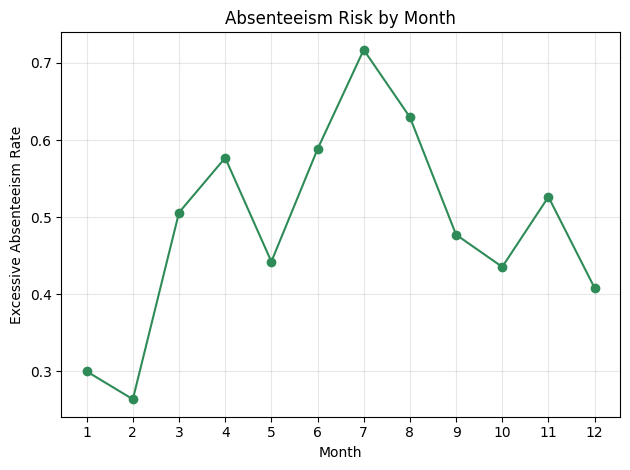

In [19]:
month_risk = df.groupby('month_value')['excessive_absenteeism'].mean()

month_risk.plot(kind='line', marker='o', color='seagreen')
plt.ylabel("Excessive Absenteeism Rate")
plt.xlabel("Month")
plt.title("Absenteeism Risk by Month")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/risk_by_month.png', dpi=150)
plt.show()

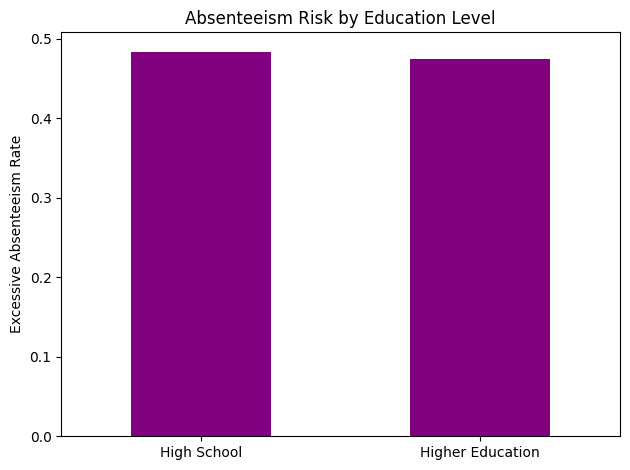

In [20]:
edu_risk = df.groupby('education_binary')['excessive_absenteeism'].mean()
edu_risk.index = ['High School', 'Higher Education']

edu_risk.plot(kind='bar', color='purple')
plt.ylabel("Excessive Absenteeism Rate")
plt.title("Absenteeism Risk by Education Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/risk_by_education.png', dpi=150)
plt.show()

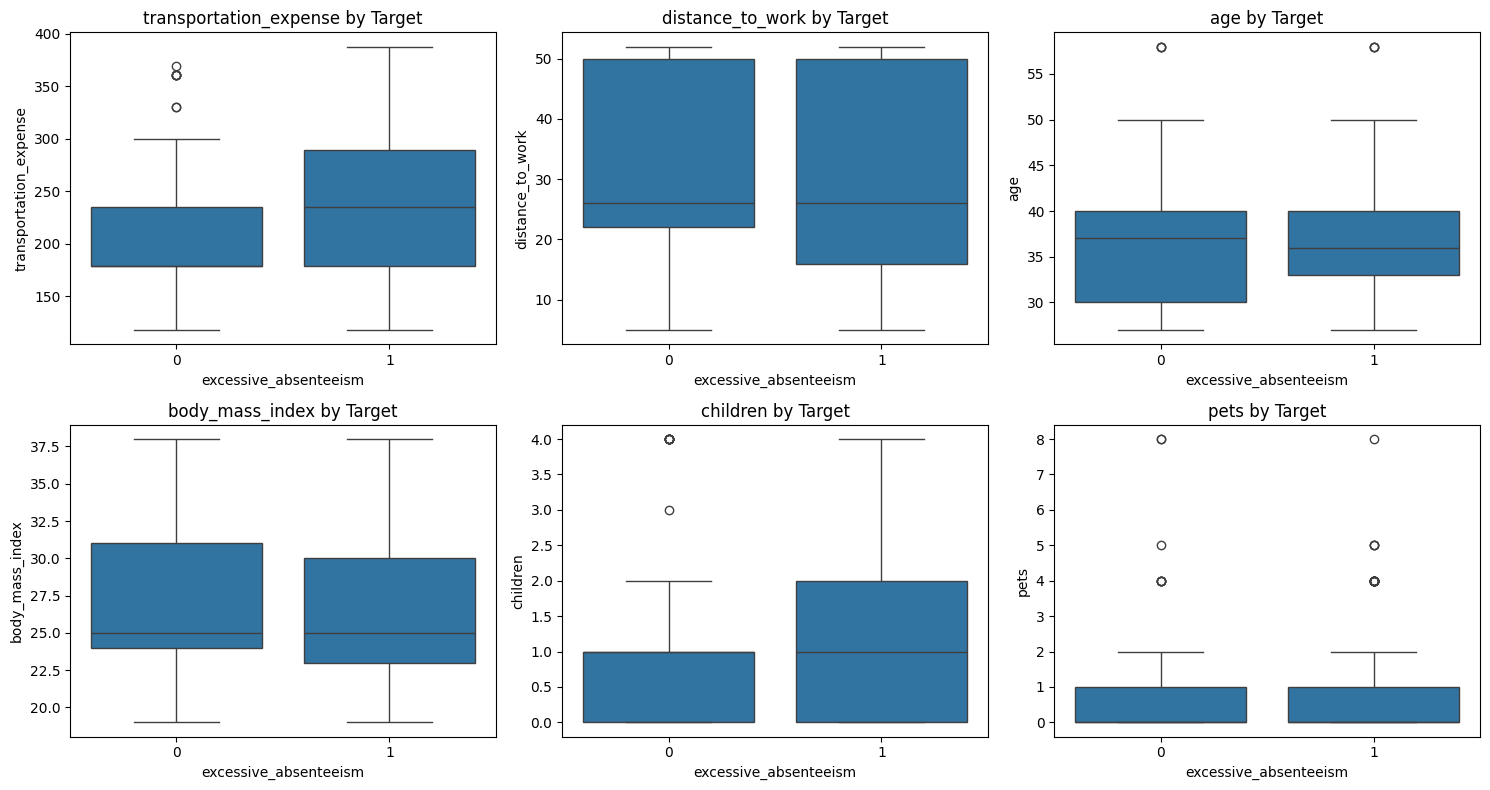

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

box_cols = ['transportation_expense', 'distance_to_work', 'age',
            'body_mass_index', 'children', 'pets']

for i, col in enumerate(box_cols):
    sns.boxplot(data=df, x='excessive_absenteeism', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Target')

plt.tight_layout()
plt.savefig('../reports/figures/boxplots_by_target.png', dpi=150)
plt.show()

## Key EDA Findings
- Target is well-balanced (~52% / 48%), no class-imbalance correction needed for modeling.
- [Fill in after reviewing plots]: which reason category shows highest risk, which age bracket, any seasonal pattern, any features with strong correlation to the target.
- These findings will be carried into the Power BI dashboard narrative for non-technical stakeholders.